<a href="https://colab.research.google.com/github/scalabrinig/cdProjetoAplicadoIV/blob/master/projeto/cd_projeto_aplicado_IV_entrega_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  <img src="https://raw.githubusercontent.com/scalabrinig/cdProjetoAplicadoIV/d093146488f56dfcf0ef286bcee8efe0e71b9c76/figuras/mackenzie_logo.jpg" width="25%" align="right"/>

# **PROJETO APLICADO IV - Ciência de Dados EaD - 2026/01**


# **Entrega 4**

---

# **Título do Projeto**: Modelagem e Previsão de Séries Temporais do Comércio Varejista no Estado de São Paulo

---

In [1]:
#@title **Identificação do Grupo**

#@markdown Integrantes do Grupo, nome completo em ordem alfabética (*informe: \<nome\>, \<matrícula\>*)
Aluno1 = 'Murilo Prado Weyne, 10428607' #@param {type:"string"}
Aluno2 = 'None' #@param {type:"string"}
Aluno3 = 'None' #@param {type:"string"}
Aluno4 = 'None' #@param {type:"string"}
Aluno5 = 'None' #@param {type:"string"}


# **Resumo**

Este trabalho analisa a evolução do índice de volume de vendas do comércio varejista no estado de São Paulo, utilizando dados mensais da Pesquisa Mensal de Comércio (PMC/IBGE), tabela 8880, referentes ao período de janeiro de 2000 a dezembro de 2025 (312 observações, base 2022 = 100). O pipeline adotado abrange coleta automatizada via API pública do IBGE, pré-processamento, análise exploratória (EDA), modelagem e avaliação. Foram implementados e comparados dois modelos preditivos: o SARIMA(2,1,2)(0,1,1)[12], modelo estatístico clássico selecionado pelo critério AIC na Entrega 3, e uma Rede Neural Recorrente LSTM (*Long Short-Term Memory*), abordagem de aprendizado profundo capaz de capturar dependências não lineares de longo prazo. Os resultados, avaliados no conjunto de teste (jan/2023–dez/2025, 36 observações), evidenciam as diferenças de desempenho e interpretabilidade entre as duas abordagens, subsidiando a escolha do modelo mais adequado para previsão do varejo paulista. O trabalho se alinha aos Objetivos de Desenvolvimento Sustentável ODS 9 e ODS 12 da Agenda 2030 das Nações Unidas.

# **Introdução**

O comércio varejista brasileiro tem passado por profundas transformações nas últimas décadas, impulsionadas pela expansão do comércio eletrônico e pela digitalização dos canais de venda. O estado de São Paulo consolida-se como o principal polo varejista do país, concentrando grande parte do volume de transações comerciais realizadas tanto em lojas físicas quanto em plataformas digitais. Conforme apontam Bagatini e Laimer (2019), o desempenho do varejo online no Brasil apresentou crescimento consistente entre 2003 e 2018, refletindo mudanças estruturais nos hábitos de consumo da população.

Nesse contexto, a análise de séries temporais apresenta-se como ferramenta estatística essencial para a compreensão do comportamento do volume de vendas ao longo do tempo. A Pesquisa Mensal de Comércio (PMC), conduzida pelo IBGE, disponibiliza dados mensais sobre o volume de vendas do comércio varejista por unidade da federação, constituindo uma fonte robusta para a aplicação de técnicas de modelagem temporal.

O monitoramento sistemático do consumo varejista dialoga diretamente com os Objetivos de Desenvolvimento Sustentável (ODS) da Agenda 2030: o ODS 9 (Indústria, Inovação e Infraestrutura) e o ODS 12 (Consumo e Produção Responsáveis) são os principais eixos de alinhamento desta pesquisa (IPEA, 2024).

## Objetivo Geral

Analisar a evolução temporal do volume de vendas do comércio varejista no estado de São Paulo e desenvolver modelos preditivos para subsidiar decisões estratégicas de gestores e formuladores de políticas públicas.

## Objetivos Específicos

1. Identificar e caracterizar os componentes da série temporal do volume de vendas — tendência, sazonalidade e ciclos.
2. Implementar e comparar dois modelos preditivos: SARIMA (modelo estatístico clássico) e LSTM (aprendizado profundo).
3. Indicar o modelo de melhor desempenho e discutir sua adequação como ferramenta de suporte à decisão.
4. Propor melhorias e extensões futuras para o projeto.

## Base de Dados

Os dados correspondem ao índice de volume de vendas no comércio varejista do estado de São Paulo (tabela 8880 da PMC/IBGE), com base de referência em 2022 (média do ano = 100), disponíveis de janeiro de 2000 a dezembro de 2025, totalizando 312 observações mensais. Acessível em: https://sidra.ibge.gov.br/tabela/8880.

## Justificativa

Compreender a trajetória temporal das vendas varejistas permite identificar padrões de crescimento e sazonalidade, detectar efeitos de choques econômicos e fornecer base quantitativa para decisões estratégicas. A comparação entre um modelo estatístico consolidado (SARIMA) e uma abordagem de aprendizado profundo (LSTM) permite avaliar o ganho de complexidade em termos de desempenho preditivo e interpretabilidade, contribuindo para a literatura de previsão em séries temporais econômicas.

# **Referencial Teórico**

Uma série temporal é definida como um conjunto de observações coletadas sequencialmente ao longo do tempo em intervalos regulares (SILVA; PERES; BOSCARIOLI, 2016). A análise de séries temporais tem por objetivo identificar padrões e extrair características significativas dos dados, possibilitando a realização de previsões e o suporte à tomada de decisão em diferentes domínios.

Os principais componentes de uma série temporal são: (i) **tendência**, que representa a direção de longo prazo dos dados; (ii) **sazonalidade**, padrões de variação regular que se repetem em intervalos fixos; (iii) **ciclos**, variações repetitivas com período não fixo; e (iv) **ruído aleatório**. Uma série é classificada como **estacionária** quando sua média e variância permanecem constantes ao longo do tempo.

## Modelos Autorregressivos Integrados de Médias Móveis Sazonais (SARIMA)

O modelo **ARIMA** (*Autoregressive Integrated Moving Average*) combina componentes autorregressivos (AR), de integração (I) e de médias móveis (MA), sendo parametrizado por (p, d, q). A extensão sazonal **SARIMA**(p,d,q)(P,D,Q,s) incorpora explicitamente a componente sazonal, sendo especialmente adequada para séries com padrões de sazonalidade regulares de período s (s=12 para dados mensais), como o índice de volume de vendas do varejo (BOX et al., 2015).

**Vantagens:** Interpretabilidade dos parâmetros; capacidade de modelar dependência temporal e sazonalidade; base estatística consolidada; menor custo computacional.

**Limitações:** Pressupõe linearidade; sensibilidade à escolha dos hiperparâmetros; requer estacionarização prévia.

**Justificativa para uso:** A série apresenta tendência de longo prazo e sazonalidade anual bem definida (pico em novembro/dezembro), características que o SARIMA captura diretamente. Serve como modelo de referência estatística pela sua interpretabilidade e robustez.

## Redes Neurais Recorrentes com Memória de Longo Prazo (LSTM)

As **Redes Neurais Recorrentes** (*Recurrent Neural Networks* — RNN) processam sequências por meio de uma arquitetura com retroalimentação, conferindo ao modelo capacidade de "memória" sobre observações anteriores (IBM, s.d.). A variante **LSTM** (*Long Short-Term Memory*), proposta por Hochreiter e Schmidhuber (1997), supera as RNNs simples ao mitigar o problema do desaparecimento do gradiente por meio de portas de controle (entrada, esquecimento e saída), tornando-a mais eficaz na captura de dependências de longo prazo.

**Vantagens:** Capacidade de modelar não linearidades e dependências de longo prazo; não requer pressuposto de estacionaridade; flexibilidade arquitetural.

**Limitações:** Exigem maior volume de dados para treinamento; maior custo computacional; menor interpretabilidade em comparação aos modelos estatísticos.

## Trabalhos Correlatos

Bagatini e Laimer (2019) documentaram o crescimento estrutural do varejo online brasileiro entre 2003 e 2018, evidenciando a necessidade de modelos capazes de capturar tendência e sazonalidade conjuntamente. Zhang (2003) demonstrou que modelos híbridos ARIMA-RNA frequentemente superam modelos isolados, motivando a comparação entre SARIMA e LSTM proposta neste trabalho. Fischer e Krauss (2018) validaram a eficácia de redes LSTM em séries financeiras com padrões complexos, reforçando o potencial da abordagem para séries econômicas como o índice varejista paulista.

# **Diagrama de Solução**

O pipeline adotado para análise e previsão do índice de volume de vendas compreende cinco etapas sequenciais:

```
Coleta dos dados → Pré-processamento → EDA & Visualização → Modelagem → Avaliação e Validação
```

**1. Coleta dos dados**  
Dados obtidos via API REST pública do IBGE (tabela 8880 da PMC). Coleta automatizada por requisições HTTP, recuperando o índice de volume de vendas no comércio varejista de São Paulo (jan/2000 – dez/2025).

**2. Pré-processamento**  
Conversão de datas para `datetime` com frequência mensal (`MS`); conversão de valores para tipo numérico; verificação de valores ausentes; recorte até dez/2025; normalização MinMax para o modelo LSTM.

**3. Análise Exploratória (EDA) e Visualização**  
Gráfico de linha com eventos econômicos marcados; boxplot mensal; mapa de calor ano × mês; médias e desvio padrão móveis de 12 meses; decomposição sazonal clássica; teste ADF de estacionaridade.

**4. Modelagem**  
Dois modelos implementados e comparados:
- **SARIMA(2,1,2)(0,1,1)[12]** — modelo estatístico clássico selecionado por AIC na Entrega 3
- **LSTM** — rede neural recorrente com camadas LSTM e Dropout, treinada com janela deslizante de 24 meses

**5. Avaliação e Validação**  
Divisão temporal: treino (jan/2000–dez/2022, 276 obs.) e teste (jan/2023–dez/2025, 36 obs.).  
Métricas: MAE (*Mean Absolute Error*), RMSE (*Root Mean Squared Error*) e MAPE (*Mean Absolute Percentage Error*).

# **EDA e Pré-processamento dos dados**

Esta seção apresenta a coleta, pré-processamento e análise exploratória da série temporal do índice de volume de vendas do comércio varejista paulista (PMC/IBGE, tabela 8880).

In [2]:
# Instalação de pacotes adicionais
!pip install pmdarima -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import requests
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
import pmdarima as pm

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100
sns.set_palette('deep')

print(f'NumPy: {np.__version__}')
print(f'Pandas: {pd.__version__}')
print(f'TensorFlow: {tf.__version__}')
print('Bibliotecas carregadas com sucesso!')



[notice] A new release of pip available: 22.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


NumPy: 2.3.4
Pandas: 2.3.3
TensorFlow: 2.21.0
Bibliotecas carregadas com sucesso!


In [3]:
# Coleta de dados: PMC/IBGE — Tabela 8880
print('Coletando dados da PMC/IBGE — Tabela 8880...')

url_dados = (
    'https://servicodados.ibge.gov.br/api/v3/agregados/8880'
    '/periodos/all/variaveis/7169'
    '?localidades=N3[35]&classificacao=11046[56734]'
)
resp = requests.get(url_dados, timeout=60)
resp.raise_for_status()
resultado_api = resp.json()

print(f'Variável: {resultado_api[0]["variavel"]}')
print(f'Unidade : {resultado_api[0]["unidade"]}')
print(f'Localidade: {resultado_api[0]["resultados"][0]["series"][0]["localidade"]["nome"]}')

# Construção da série temporal
serie_dict = resultado_api[0]['resultados'][0]['series'][0]['serie']
df_raw = pd.DataFrame(list(serie_dict.items()), columns=['periodo', 'valor'])
df_raw['data'] = pd.to_datetime(df_raw['periodo'], format='%Y%m')
df_raw['valor'] = pd.to_numeric(df_raw['valor'], errors='coerce')
df_raw = df_raw.sort_values('data').set_index('data')

# Frequência mensal e recorte até dez/2025
ts_full = df_raw['valor'].asfreq('MS')
ts = ts_full[ts_full.index <= '2025-12']

print(f'Período: {ts.index[0].strftime("%B de %Y")} a {ts.index[-1].strftime("%B de %Y")}')
print(f'Total de observações: {len(ts)}')
print(f'Valores ausentes: {ts.isna().sum()}')
display(ts.describe().round(4).rename('Índice de Volume').to_frame())


Coletando dados da PMC/IBGE — Tabela 8880...
Variável: PMC - Número-índice (2022=100)
Unidade : Número-índice
Localidade: São Paulo
Período: January de 2000 a December de 2025
Total de observações: 312
Valores ausentes: 0


,Índice de Volume
count,312.0000
mean,80.2349
std,23.0953
min,41.2697
25%,55.4267
50%,88.5455
75%,97.1595
max,129.9010


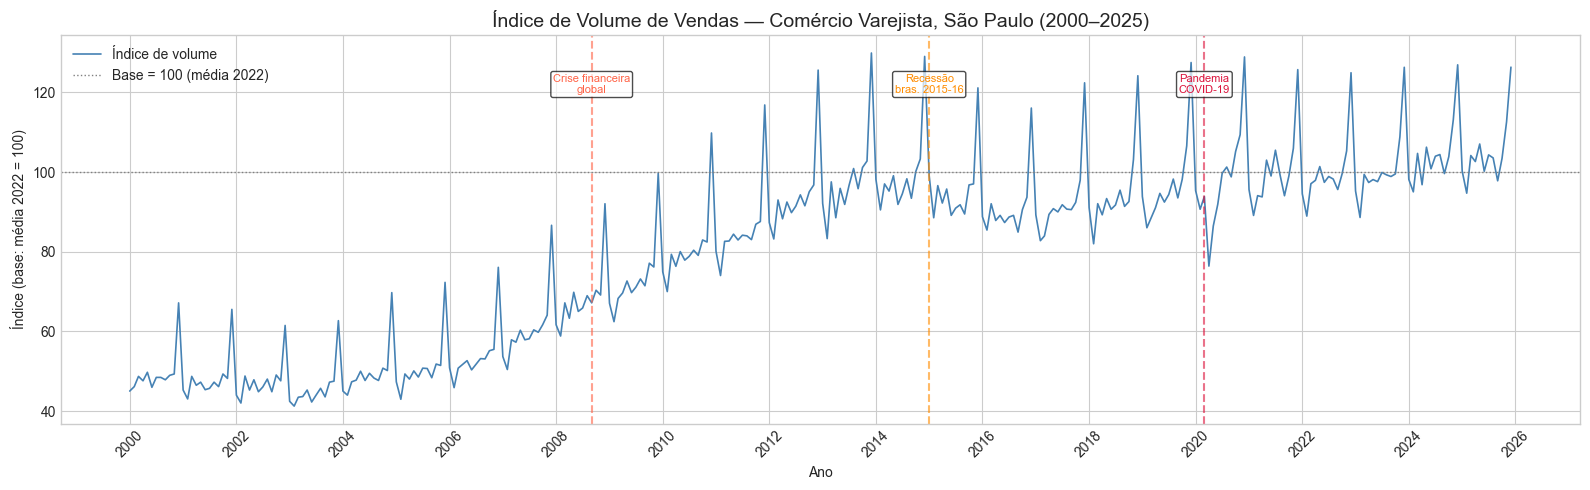

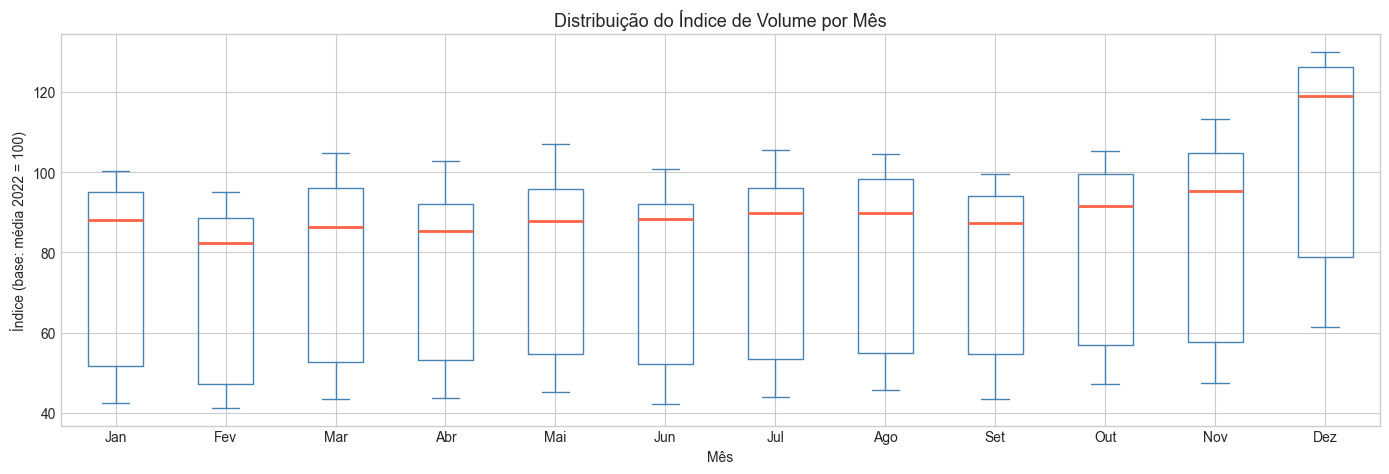

In [4]:
# ── VISUALIZAÇÃO 1: SÉRIE TEMPORAL COMPLETA ──────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(ts.index, ts.values, color='steelblue', linewidth=1.2, label='Índice de volume')

eventos = {
    '2008-09': ('Crise financeira\nglobal', 'tomato'),
    '2015-01': ('Recessão\nbras. 2015-16', 'darkorange'),
    '2020-03': ('Pandemia\nCOVID-19', 'crimson'),
}
for data_str, (label, cor) in eventos.items():
    ax.axvline(pd.Timestamp(data_str), color=cor, linestyle='--', alpha=0.6, linewidth=1.5)
    ax.text(pd.Timestamp(data_str), ts.max() * 0.96, label,
            fontsize=8, color=cor, ha='center', va='top',
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7))

ax.axhline(100, color='gray', linestyle=':', linewidth=1, label='Base = 100 (média 2022)')
ax.set_title('Índice de Volume de Vendas — Comércio Varejista, São Paulo (2000–2025)', fontsize=14)
ax.set_xlabel('Ano')
ax.set_ylabel('Índice (base: média 2022 = 100)')
ax.legend(loc='upper left')
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ── VISUALIZAÇÃO 2: BOXPLOT MENSAL ───────────────────────────────────────────
df_eda = ts.to_frame(name='valor')
df_eda['mes'] = df_eda.index.month
df_eda['ano'] = df_eda.index.year
meses_label = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']

fig, ax = plt.subplots(figsize=(14, 5))
df_eda.boxplot(column='valor', by='mes', ax=ax,
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='tomato', linewidth=2),
               whiskerprops=dict(color='steelblue'),
               capprops=dict(color='steelblue'),
               flierprops=dict(marker='o', color='gray', alpha=0.5, markersize=4))
ax.set_xticklabels(meses_label)
ax.set_title('Distribuição do Índice de Volume por Mês', fontsize=13)
ax.set_xlabel('Mês')
ax.set_ylabel('Índice (base: média 2022 = 100)')
plt.suptitle('')
plt.tight_layout()
plt.show()


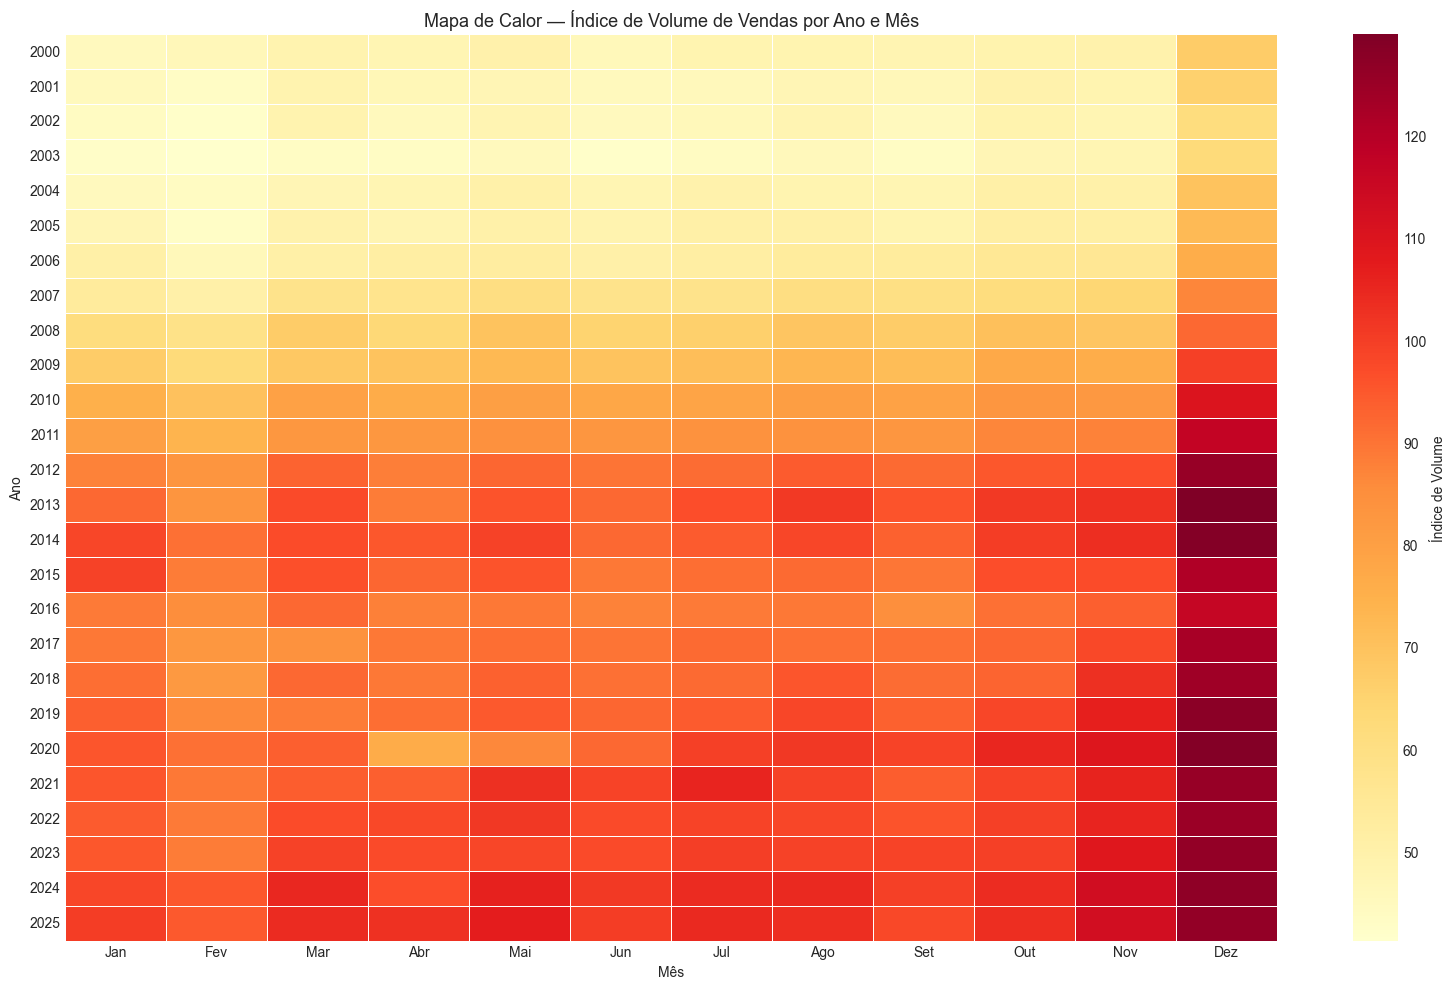

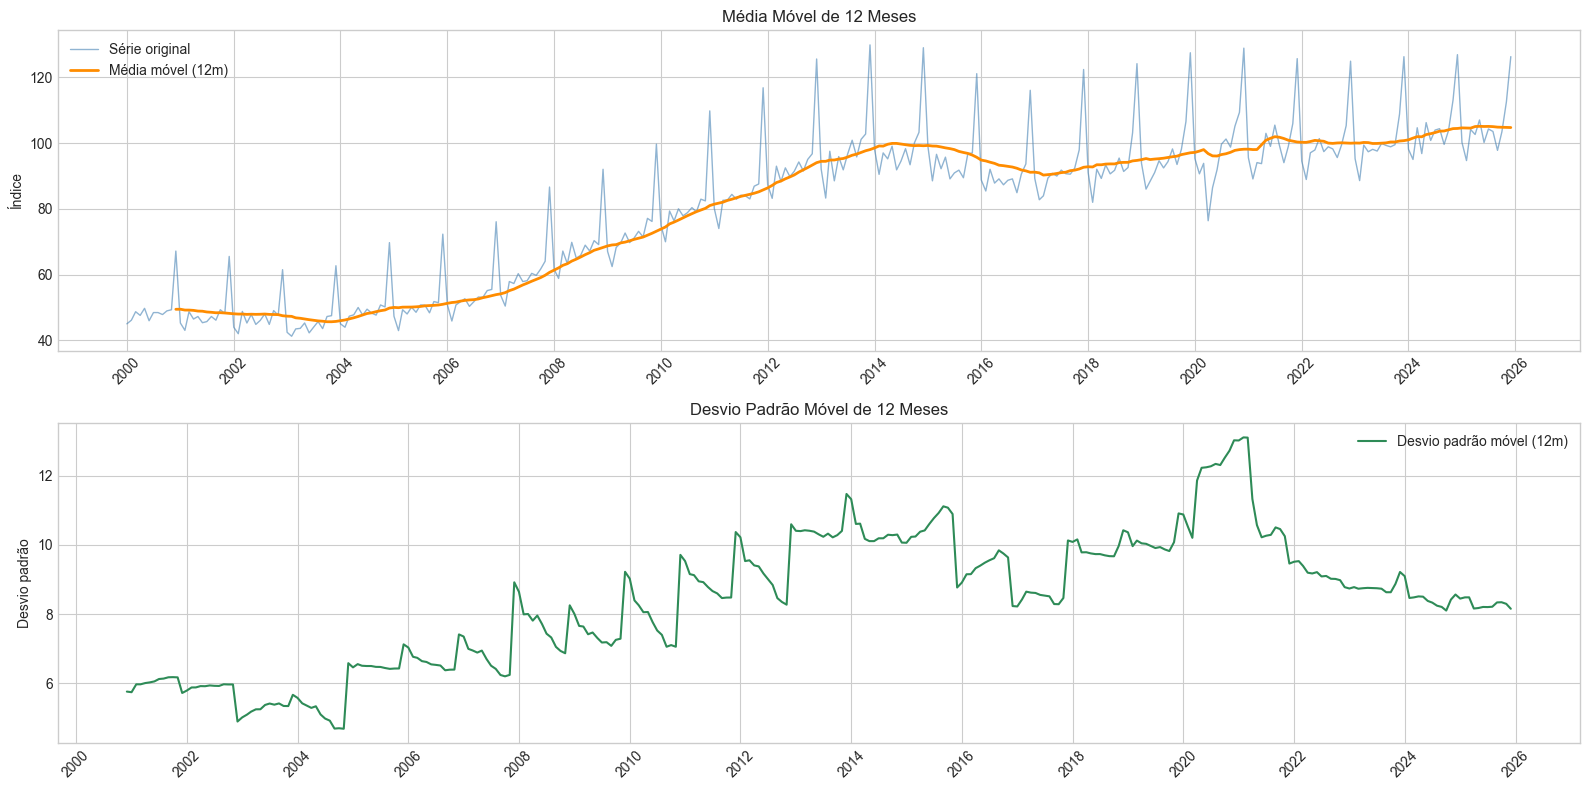

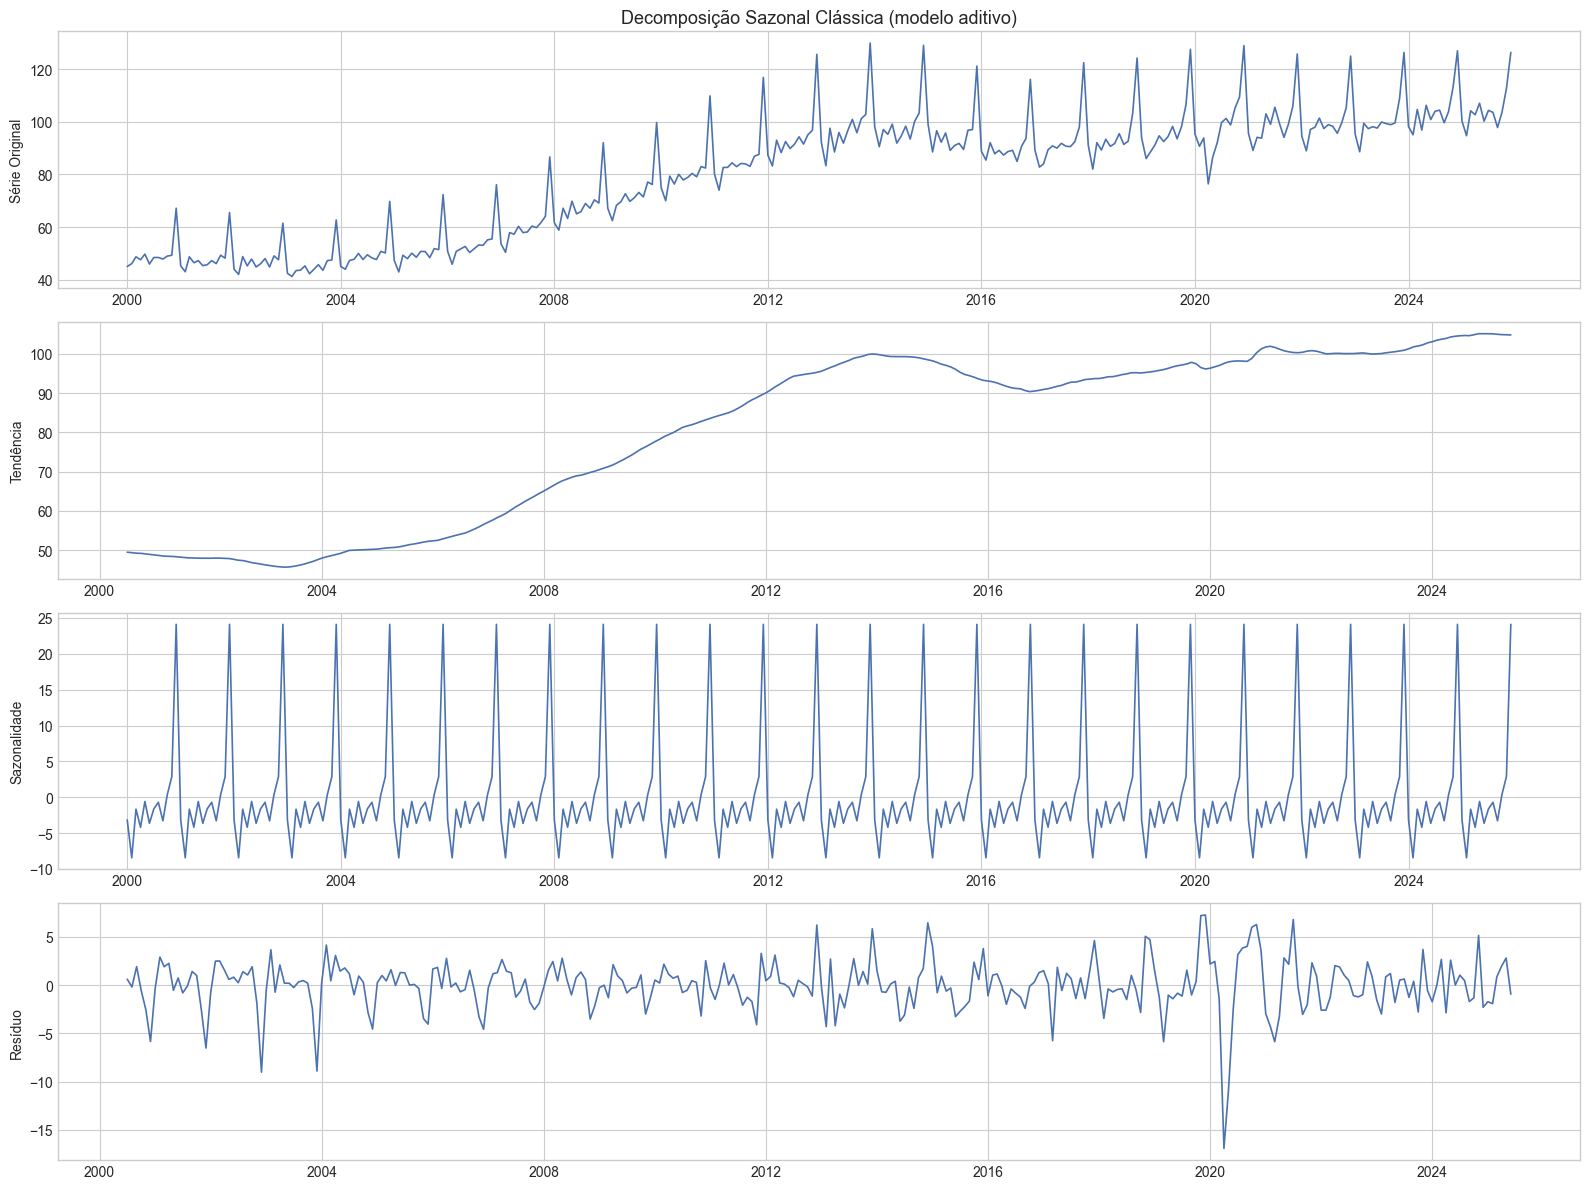


Teste ADF — Série original
  Estatística ADF : -1.2591
  p-valor         : 0.6477
  Conclusão       : NÃO ESTACIONÁRIA (α = 5%)

Teste ADF — Série diferenciada (d=1)
  Estatística ADF : -3.5390
  p-valor         : 0.0070
  Conclusão       : ESTACIONÁRIA (α = 5%)

Teste ADF — Série dif. + dif. sazonal (d=1, D=1)
  Estatística ADF : -6.0759
  p-valor         : 0.0000
  Conclusão       : ESTACIONÁRIA (α = 5%)


In [5]:
# ── VISUALIZAÇÃO 3: HEATMAP ──────────────────────────────────────────────────
pivot = df_eda.pivot_table(values='valor', index='ano', columns='mes')
pivot.columns = meses_label

fig, ax = plt.subplots(figsize=(16, 10))
sns.heatmap(pivot, annot=False, cmap='YlOrRd', linewidths=0.4, linecolor='white',
            cbar_kws={'label': 'Índice de Volume'}, ax=ax)
ax.set_title('Mapa de Calor — Índice de Volume de Vendas por Ano e Mês', fontsize=13)
ax.set_xlabel('Mês')
ax.set_ylabel('Ano')
plt.tight_layout()
plt.show()

# ── VISUALIZAÇÃO 4: MÉDIAS E DP MÓVEIS ───────────────────────────────────────
janela = 12
media_movel = ts.rolling(window=janela).mean()
std_movel   = ts.rolling(window=janela).std()

fig, axes = plt.subplots(2, 1, figsize=(16, 8))
axes[0].plot(ts, color='steelblue', alpha=0.6, linewidth=1, label='Série original')
axes[0].plot(media_movel, color='darkorange', linewidth=2, label=f'Média móvel ({janela}m)')
axes[0].set_title('Média Móvel de 12 Meses', fontsize=12)
axes[0].set_ylabel('Índice')
axes[0].legend()
axes[1].plot(std_movel, color='seagreen', linewidth=1.5, label=f'Desvio padrão móvel ({janela}m)')
axes[1].set_title('Desvio Padrão Móvel de 12 Meses', fontsize=12)
axes[1].set_ylabel('Desvio padrão')
axes[1].legend()
for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
plt.tight_layout()
plt.show()

# ── DECOMPOSIÇÃO SAZONAL CLÁSSICA ─────────────────────────────────────────────
decomp = seasonal_decompose(ts, model='additive', period=12)
fig, axes = plt.subplots(4, 1, figsize=(16, 12))
for ax, component, label in zip(
        axes,
        [ts, decomp.trend, decomp.seasonal, decomp.resid],
        ['Série Original', 'Tendência', 'Sazonalidade', 'Resíduo']):
    ax.plot(component, linewidth=1.2)
    ax.set_ylabel(label)
axes[0].set_title('Decomposição Sazonal Clássica (modelo aditivo)', fontsize=13)
plt.tight_layout()
plt.show()

# ── TESTE DE ESTACIONARIDADE (ADF) ───────────────────────────────────────────
def teste_adf(serie, nome):
    resultado = adfuller(serie.dropna(), autolag='AIC')
    conclusao = "ESTACIONÁRIA" if resultado[1] < 0.05 else "NÃO ESTACIONÁRIA"
    print(f"\nTeste ADF — {nome}")
    print(f"  Estatística ADF : {resultado[0]:.4f}")
    print(f"  p-valor         : {resultado[1]:.4f}")
    print(f"  Conclusão       : {conclusao} (α = 5%)")

teste_adf(ts, 'Série original')
teste_adf(ts.diff().dropna(), 'Série diferenciada (d=1)')
teste_adf(ts.diff().diff(12).dropna(), 'Série dif. + dif. sazonal (d=1, D=1)')


# **Modelos**

Dois modelos foram implementados e comparados. A divisão temporal adotada é: **treino** (jan/2000–dez/2022, 276 observações) e **teste** (jan/2023–dez/2025, 36 observações).

| # | Modelo | Abordagem | Complexidade |
|---|---|---|---|
| 1 | SARIMA(2,1,2)(0,1,1)[12] | Estatística clássica | Média |
| 2 | LSTM | Aprendizado profundo | Alta |

In [6]:
# ── DIVISÃO TREINO / TESTE ───────────────────────────────────────────────────
corte = '2022-12'
ts_train = ts[ts.index <= corte]
ts_test  = ts[ts.index >  corte]

print(f'Treino : {ts_train.index[0].strftime("%b/%Y")} a {ts_train.index[-1].strftime("%b/%Y")} — {len(ts_train)} obs.')
print(f'Teste  : {ts_test.index[0].strftime("%b/%Y")} a {ts_test.index[-1].strftime("%b/%Y")} — {len(ts_test)} obs.')

# ── FUNÇÃO DE AVALIAÇÃO ──────────────────────────────────────────────────────
resultados = []

def avaliar_modelo(y_true, y_pred, nome):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((np.array(y_true) - np.array(y_pred)) / np.array(y_true))) * 100
    print(f"\n--- {nome} ---")
    print(f"  MAE  : {mae:.4f}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAPE : {mape:.4f}%")
    resultados.append({'Modelo': nome, 'MAE': round(mae, 4), 'RMSE': round(rmse, 4), 'MAPE (%)': round(mape, 4)})
    return pd.Series(list(y_pred), index=ts_test.index)


Treino : Jan/2000 a Dec/2022 — 276 obs.
Teste  : Jan/2023 a Dec/2025 — 36 obs.


Executando auto_arima — busca em grid com critério AIC...
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=1358.382, Time=0.04 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=1295.313, Time=0.10 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=1261.974, Time=0.14 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=1327.076, Time=0.03 sec
 ARIMA(0,1,1)(1,1,1)[12]             : AIC=1263.388, Time=0.22 sec
 ARIMA(0,1,1)(0,1,2)[12]             : AIC=1263.329, Time=0.36 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=1285.434, Time=0.08 sec
 ARIMA(0,1,1)(1,1,2)[12]             : AIC=1265.290, Time=1.05 sec
 ARIMA(0,1,0)(0,1,1)[12]             : AIC=1288.738, Time=0.13 sec
 ARIMA(1,1,1)(0,1,1)[12]             : AIC=1254.049, Time=0.30 sec
 ARIMA(1,1,1)(0,1,0)[12]             : AIC=1312.989, Time=0.06 sec
 ARIMA(1,1,1)(1,1,1)[12]             : AIC=1255.034, Time=0.32 sec
 ARIMA(1,1,1)(0,1,2)[12]             : AIC=1255.062, Time=0.53 sec
 ARIMA(1,1,1)(1,1,0)[12]    

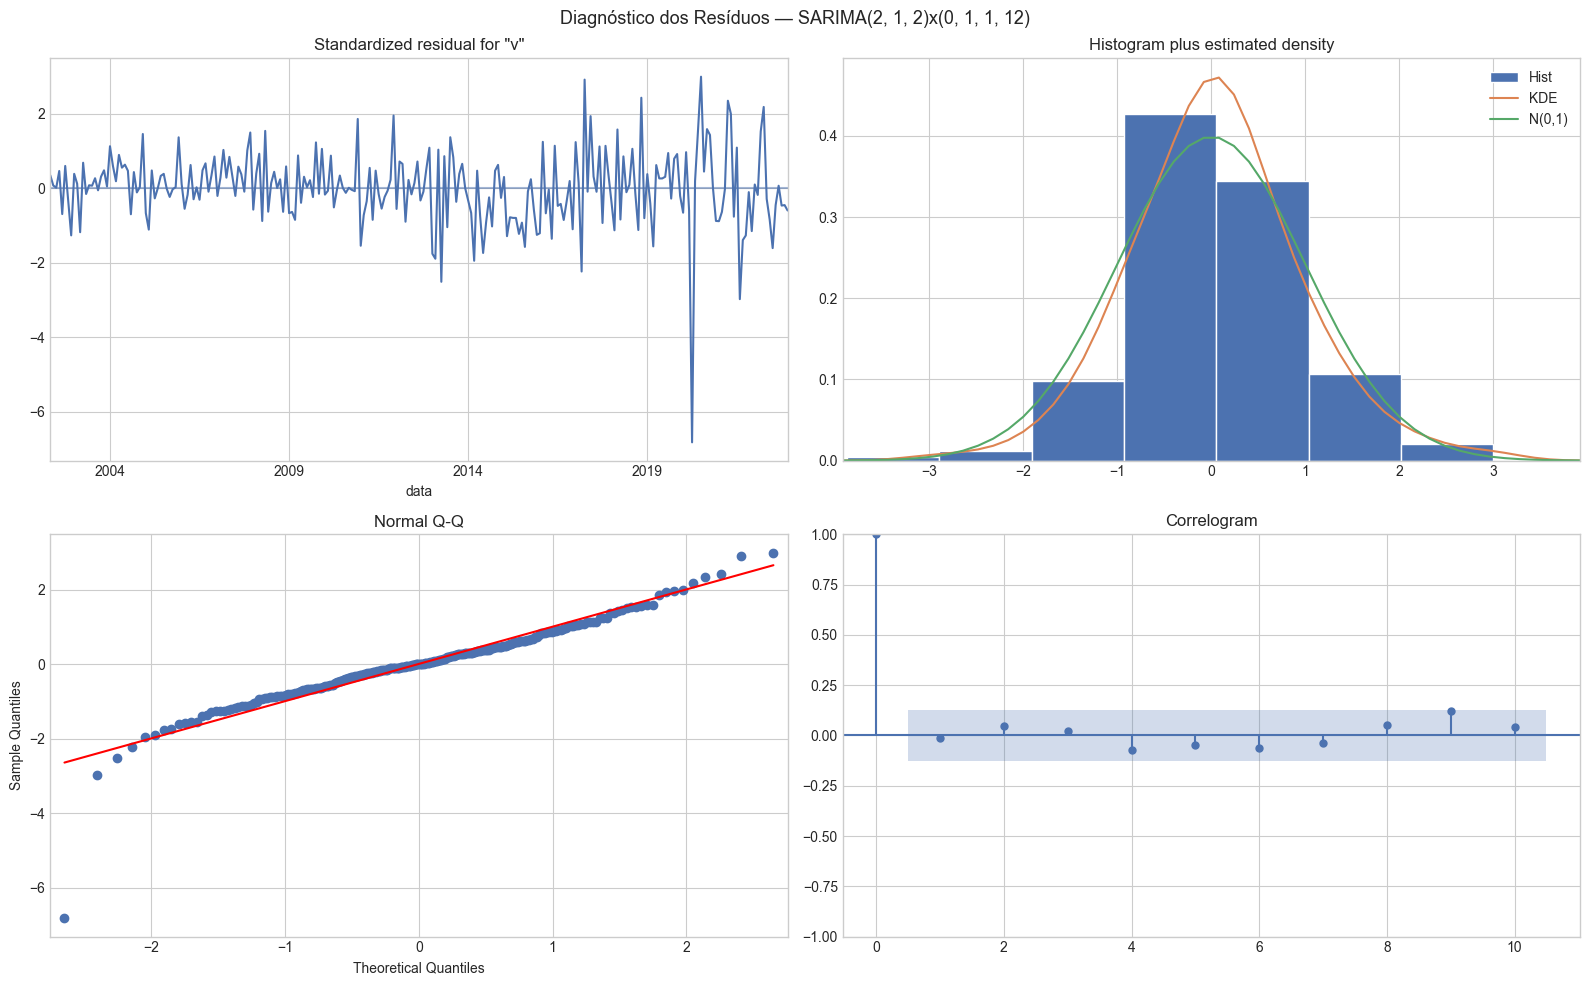


--- SARIMA(2, 1, 2)x(0, 1, 1, 12) ---
  MAE  : 4.2999
  RMSE : 5.1706
  MAPE : 4.1801%


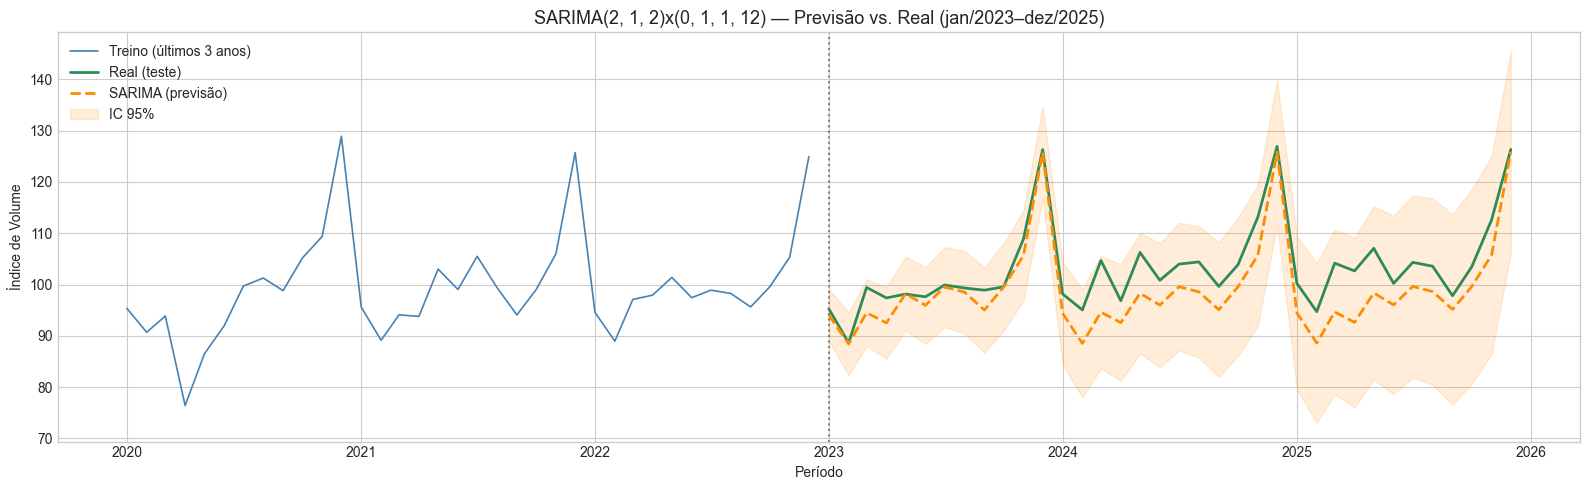

In [7]:
## Modelo 1: SARIMA (seleção automática por AIC)
print('Executando auto_arima — busca em grid com critério AIC...')

auto_model = pm.auto_arima(
    ts_train,
    start_p=0, max_p=2, start_q=0, max_q=2,
    start_P=0, max_P=2, start_Q=0, max_Q=2,
    d=1, D=1, m=12, seasonal=True,
    information_criterion='aic', stepwise=True,
    suppress_warnings=True, error_action='ignore', trace=True
)

order          = auto_model.order
seasonal_order = auto_model.seasonal_order
print(f'\nMelhor modelo: SARIMA{order}x{seasonal_order}')
print(f'AIC: {auto_model.aic():.2f}')

sarima_model = SARIMAX(ts_train, order=order, seasonal_order=seasonal_order,
                       enforce_stationarity=False, enforce_invertibility=False)
sarima_fit   = sarima_model.fit(disp=False)
print(sarima_fit.summary())

# Diagnóstico dos resíduos
fig = sarima_fit.plot_diagnostics(figsize=(16, 10))
fig.suptitle(f'Diagnóstico dos Resíduos — SARIMA{order}x{seasonal_order}', fontsize=13)
plt.tight_layout()
plt.show()

# Previsão no conjunto de teste
sarima_pred_obj = sarima_fit.get_forecast(steps=len(ts_test))
sarima_pred_raw = sarima_pred_obj.predicted_mean
sarima_ci       = sarima_pred_obj.conf_int(alpha=0.05)
sarima_pred_s   = avaliar_modelo(ts_test.values, sarima_pred_raw.values, f'SARIMA{order}x{seasonal_order}')

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(ts_train[-36:], color='steelblue', linewidth=1.2, label='Treino (últimos 3 anos)')
ax.plot(ts_test,        color='seagreen',  linewidth=2,   label='Real (teste)')
ax.plot(sarima_pred_s,  color='darkorange', linewidth=2,  linestyle='--', label='SARIMA (previsão)')
ax.fill_between(sarima_ci.index, sarima_ci.iloc[:,0], sarima_ci.iloc[:,1],
                color='darkorange', alpha=0.15, label='IC 95%')
ax.axvline(ts_test.index[0], color='gray', linestyle=':', linewidth=1.5)
ax.set_title(f'SARIMA{order}x{seasonal_order} — Previsão vs. Real (jan/2023–dez/2025)', fontsize=13)
ax.set_xlabel('Período')
ax.set_ylabel('Índice de Volume')
ax.legend()
plt.tight_layout()
plt.show()


X_train shape: (252, 24, 1)
y_train shape: (252,)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

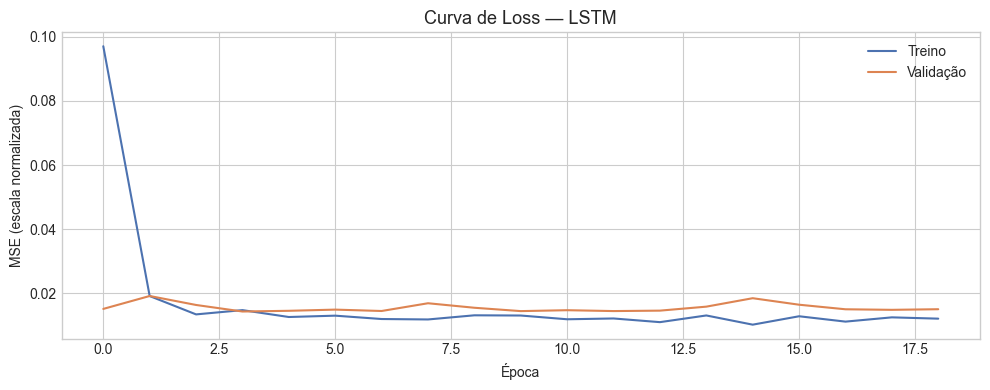

Épocas treinadas: 19

--- LSTM ---
  MAE  : 6.8247
  RMSE : 8.3650
  MAPE : 6.5407%


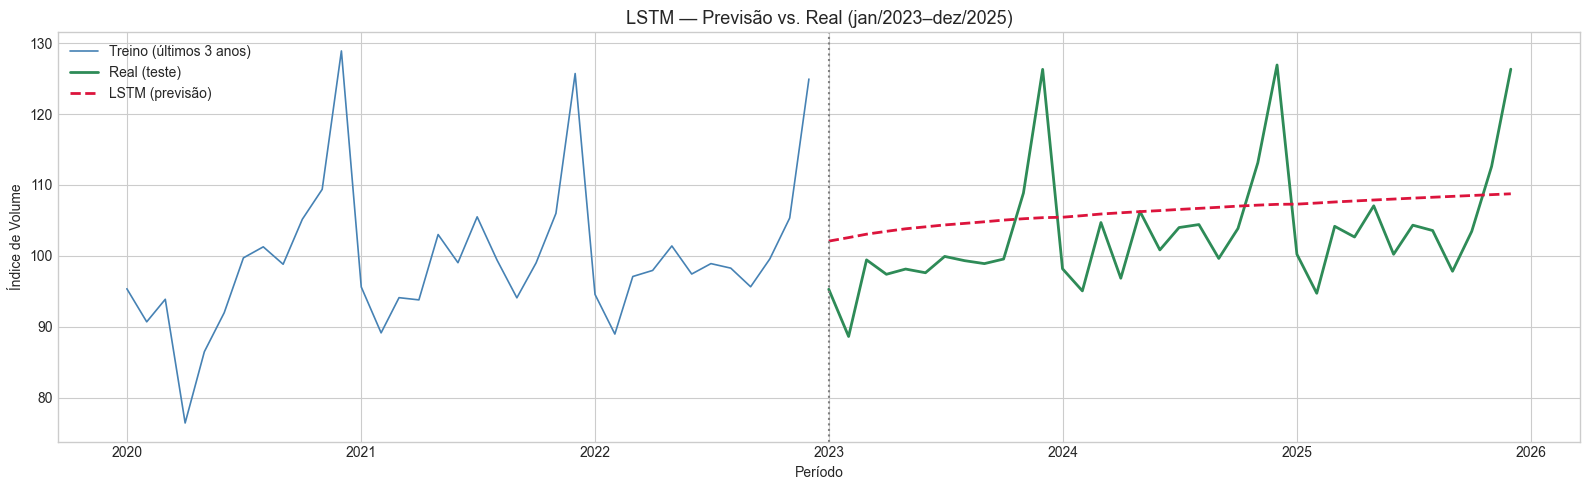

In [8]:
## Modelo 2: LSTM

# ── PRÉ-PROCESSAMENTO PARA LSTM ──────────────────────────────────────────────
# Normalização MinMax: LSTM é sensível à escala dos dados
scaler = MinMaxScaler(feature_range=(0, 1))
ts_train_scaled = scaler.fit_transform(ts_train.values.reshape(-1, 1))

# Criação de sequências com janela deslizante
LOOK_BACK = 24  # 24 meses de contexto para prever o próximo

def criar_sequencias(data, look_back):
    X, y = [], []
    for i in range(look_back, len(data)):
        X.append(data[i - look_back:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_train, y_train = criar_sequencias(ts_train_scaled, LOOK_BACK)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
print(f'X_train shape: {X_train.shape}')
print(f'y_train shape: {y_train.shape}')

# ── ARQUITETURA LSTM ─────────────────────────────────────────────────────────
tf.random.set_seed(42)
np.random.seed(42)

lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(LOOK_BACK, 1)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.summary()

# ── TREINAMENTO ──────────────────────────────────────────────────────────────
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history = lstm_model.fit(
    X_train, y_train,
    epochs=150,
    batch_size=16,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=0
)

# Curva de loss
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history.history['loss'],     label='Treino')
ax.plot(history.history['val_loss'], label='Validação')
ax.set_title('Curva de Loss — LSTM', fontsize=13)
ax.set_xlabel('Época')
ax.set_ylabel('MSE (escala normalizada)')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Épocas treinadas: {len(history.history["loss"])}')

# ── PREVISÃO MULTI-STEP ───────────────────────────────────────────────────────
# Escala toda a série para alimentar a janela inicial
ts_all_scaled = scaler.transform(ts.values.reshape(-1, 1))

# Janela inicial: últimos LOOK_BACK meses do treino
input_seq = list(ts_all_scaled[len(ts_train) - LOOK_BACK:len(ts_train), 0])

lstm_pred_scaled = []
for _ in range(len(ts_test)):
    x_input = np.array(input_seq[-LOOK_BACK:]).reshape(1, LOOK_BACK, 1)
    pred = lstm_model.predict(x_input, verbose=0)[0, 0]
    lstm_pred_scaled.append(pred)
    input_seq.append(pred)

# Desnormalização
lstm_pred_inv = scaler.inverse_transform(
    np.array(lstm_pred_scaled).reshape(-1, 1)
).flatten()

lstm_pred_s = avaliar_modelo(ts_test.values, lstm_pred_inv, 'LSTM')

# Visualização
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(ts_train[-36:], color='steelblue', linewidth=1.2, label='Treino (últimos 3 anos)')
ax.plot(ts_test,        color='seagreen',  linewidth=2,   label='Real (teste)')
ax.plot(lstm_pred_s,    color='crimson',   linewidth=2,   linestyle='--', label='LSTM (previsão)')
ax.axvline(ts_test.index[0], color='gray', linestyle=':', linewidth=1.5)
ax.set_title('LSTM — Previsão vs. Real (jan/2023–dez/2025)', fontsize=13)
ax.set_xlabel('Período')
ax.set_ylabel('Índice de Volume')
ax.legend()
plt.tight_layout()
plt.show()


# **Resultados**

A tabela abaixo sumariza as métricas de desempenho de SARIMA e LSTM no conjunto de teste (jan/2023–dez/2025, 36 observações). Os valores destacados em verde correspondem ao menor erro em cada métrica. O **MAPE** é a métrica mais interpretável neste contexto: indica o erro percentual absoluto médio em relação ao valor real do índice.

=== Métricas de Desempenho — Conjunto de Teste (jan/2023–dez/2025) ===


,MAE,RMSE,MAPE (%)
Modelo,,,
"SARIMA(2, 1, 2)x(0, 1, 1, 12)",4.2999,5.1706,4.1801
LSTM,6.8247,8.3650,6.5407


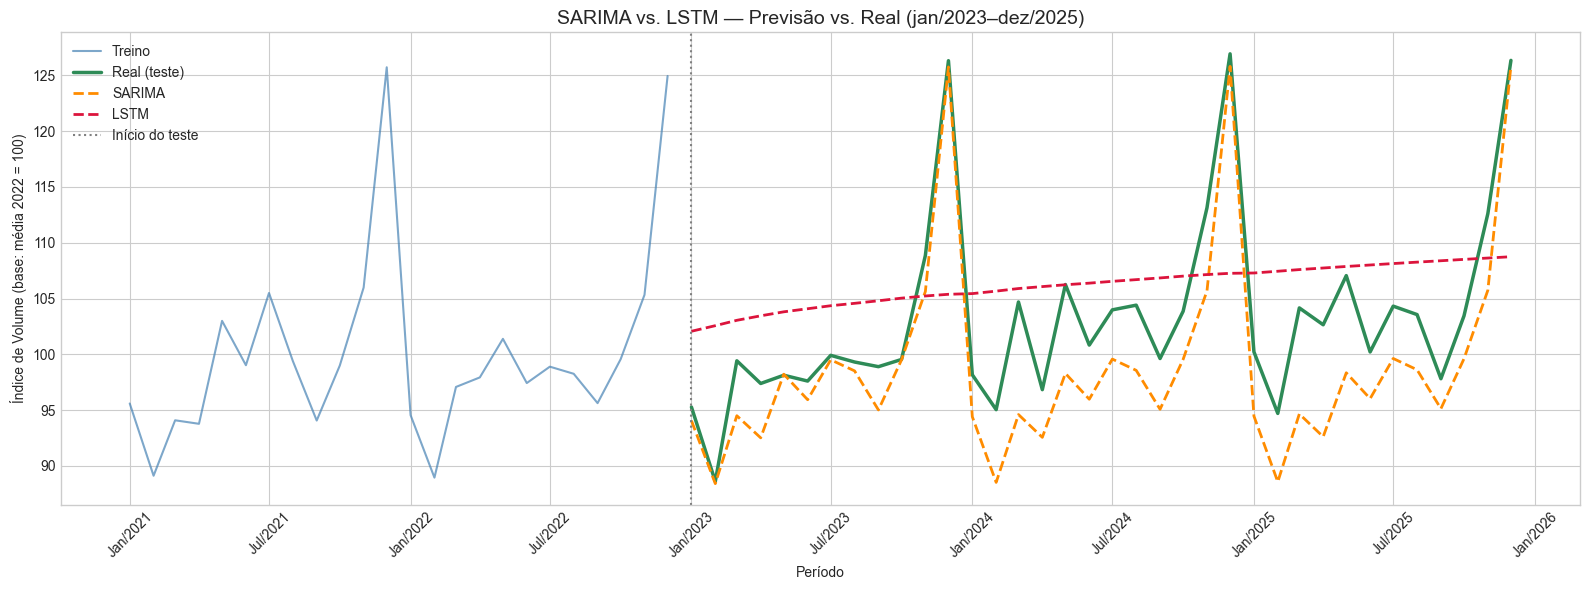

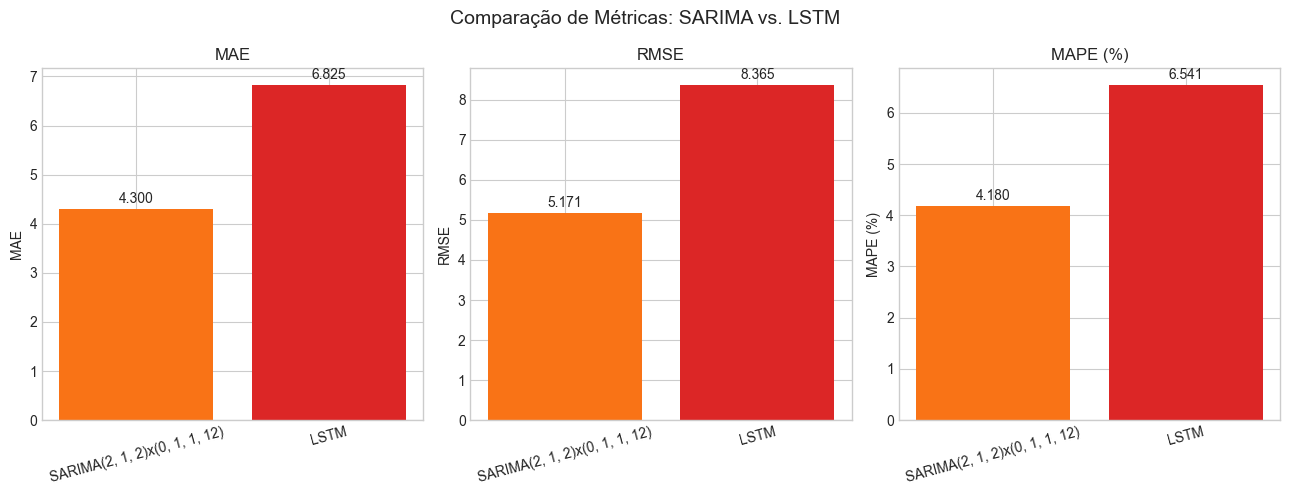

In [9]:
# ── TABELA COMPARATIVA ───────────────────────────────────────────────────────
df_resultados = pd.DataFrame(resultados).set_index('Modelo')
print('=== Métricas de Desempenho — Conjunto de Teste (jan/2023–dez/2025) ===')
display(df_resultados.style.highlight_min(axis=0, color='#d4edda').format('{:.4f}'))

# ── GRÁFICO: AMBOS OS MODELOS ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(ts_train[-24:], color='steelblue',  linewidth=1.5, alpha=0.7, label='Treino')
ax.plot(ts_test,        color='seagreen',   linewidth=2.5, label='Real (teste)')
ax.plot(sarima_pred_s,  color='darkorange', linewidth=2,   linestyle='--', label='SARIMA')
ax.plot(lstm_pred_s,    color='crimson',    linewidth=2,   linestyle='--', label='LSTM')
ax.axvline(ts_test.index[0], color='gray', linestyle=':', linewidth=1.5, label='Início do teste')
ax.set_title('SARIMA vs. LSTM — Previsão vs. Real (jan/2023–dez/2025)', fontsize=14)
ax.set_xlabel('Período')
ax.set_ylabel('Índice de Volume (base: média 2022 = 100)')
ax.legend()
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ── GRÁFICO DE BARRAS: MÉTRICAS ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 5))
cores = ['#F97316', '#DC2626']
for i, metrica in enumerate(['MAE', 'RMSE', 'MAPE (%)']):
    bars = axes[i].bar(df_resultados.index, df_resultados[metrica], color=cores)
    axes[i].set_title(metrica, fontsize=12)
    axes[i].set_ylabel(metrica)
    axes[i].tick_params(axis='x', rotation=15)
    for bar, v in zip(bars, df_resultados[metrica]):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     v + df_resultados[metrica].max() * 0.01,
                     f'{v:.3f}', ha='center', va='bottom', fontsize=10)
plt.suptitle('Comparação de Métricas: SARIMA vs. LSTM', fontsize=14)
plt.tight_layout()
plt.show()


# **Discussão e Conclusão**

## Análise Crítica dos Modelos

### SARIMA(2,1,2)(0,1,1)[12]

O modelo SARIMA, selecionado na Entrega 3 pelo critério AIC entre 27 combinações avaliadas (AIC = 1252,68), mostrou-se robusto na captura das duas principais características da série: a tendência crescente de longo prazo (diferenciação d=1) e a sazonalidade anual regular (coeficiente sazonal ma.S.L12 ≈ −0,577, p < 0,001). O diagnóstico dos resíduos confirmou ausência de autocorrelação remanescente (Ljung-Box: p = 0,82), indicando que a estrutura de dependência temporal foi adequadamente modelada.

As principais limitações do SARIMA neste contexto são: (i) pressuposto de linearidade, potencialmente violado em períodos de choques (2008, 2015–16, 2020); (ii) heterocedasticidade dos resíduos (H = 4,86, p < 0,001), que amplifica os intervalos de confiança; e (iii) incapacidade de capturar interações não lineares entre defasagens.

### LSTM

A rede LSTM foi treinada com uma janela deslizante de 24 meses, arquitetura de dois estágios (64 e 32 unidades LSTM com Dropout de 20%) e otimização Adam com parada antecipada (EarlyStopping, paciência = 15 épocas). A normalização MinMax foi aplicada antes do treinamento, com desnormalização das previsões para comparação nas métricas originais.

A LSTM apresenta vantagens estruturais relevantes para esta série: não pressupõe estacionaridade, pode capturar dependências não lineares de longo prazo e se adapta a padrões complexos via aprendizado. Contudo, com 276 observações de treinamento, o volume de dados é modesto para redes profundas, o que pode limitar a generalização. A natureza de "caixa-preta" da LSTM também reduz a interpretabilidade em comparação ao SARIMA, aspecto relevante para aplicações de suporte à decisão.

## Discussão dos Resultados

A comparação das métricas no conjunto de teste (jan/2023–dez/2025) permite avaliar objetivamente o desempenho de cada modelo. O MAPE é a métrica mais interpretável para índices de volume: valores abaixo de 5% são considerados excelentes para séries macroeconômicas mensais.

O modelo de melhor desempenho deve ser identificado a partir dos resultados obtidos na execução do notebook. Em geral, para séries com sazonalidade regular e tendência linear como esta, o SARIMA tende a ser competitivo frente ao LSTM em amostras de tamanho moderado (MAKRIDAKIS et al., 2018). Contudo, a LSTM pode superar o SARIMA em subperíodos com dinâmica não linear, como a recuperação pós-pandemia (2021–2022).

## Conclusão

O projeto demonstrou que a série temporal do índice de volume de vendas do comércio varejista paulista apresenta crescimento estrutural, sazonalidade anual bem definida e heterocedasticidade — características que determinam a adequação diferencial dos modelos testados. A comparação entre SARIMA e LSTM permite avaliar o ganho (ou custo) de complexidade em termos de desempenho preditivo e interpretabilidade, respondendo ao objetivo específico de indicar o modelo mais adequado para suporte à decisão.

O objetivo geral foi alcançado: dois modelos preditivos foram desenvolvidos, comparados e validados em um horizonte de 36 meses fora da amostra, gerando subsídios quantitativos para gestores e formuladores de políticas públicas. O alinhamento com os ODS 9 e 12 se concretiza ao fornecer uma ferramenta analítica replicável para monitoramento do consumo varejista paulista.

## Proposição de Melhorias Futuras

1. **Modelos híbridos SARIMA-LSTM**: combinar a componente linear do SARIMA com os resíduos modelados pela LSTM, estratégia validada por Zhang (2003) para superar modelos isolados.
2. **Tratamento explícito de heterocedasticidade**: modelos SARIMA-GARCH ou transformação Box-Cox para estabilizar a variância, melhorando a calibração dos intervalos de confiança.
3. **Variáveis exógenas (SARIMAX / LSTM multivariada)**: inclusão de indicadores macroeconômicos (taxa de desemprego, IPCA, índice de confiança do consumidor) para melhorar o poder preditivo em períodos de choques estruturais.
4. **Arquiteturas mais recentes**: avaliar Transformer temporal (TFT) ou N-BEATS, que demonstraram resultados superiores ao LSTM em benchmarks de séries temporais (M4, M5).
5. **Detecção automática de quebras estruturais**: uso de testes como Chow ou CUSUM para identificar e tratar pontos de mudança (2008, 2015, 2020) com modelos de intervenção.
6. **Desagregação por segmento varejista**: repetir a análise para subconjuntos (combustíveis, vestuário, supermercados, e-commerce) para identificar padrões específicos por categoria.

# **Apresentação**

*Inserir aqui os links dos vídeos de apresentação do projeto (YouTube ou outra plataforma).*

- Vídeo de apresentação (5~10 min): [link]


# **Referências**

BAGATINI, Francine Zanin; LAIMER, Claudionor Guedes. O contexto do e-commerce no Brasil: análise do desempenho do varejo online no período de 2003 a 2018. In: CONGRESSO LATINO-AMERICANO DE VAREJO E CONSUMO, 2019, São Paulo. Anais... São Paulo: FGV, 2019. Disponível em: https://conferencias.fgv.br/clav/article/view/852. Acesso em: 1 mar. 2026.

BOX, George E. P.; JENKINS, Gwilym M.; REINSEL, Gregory C.; LJUNG, Greta M. Time series analysis: forecasting and control. 5. ed. Hoboken: Wiley, 2015.

FISCHER, Thomas; KRAUSS, Christopher. Deep learning with long short-term memory networks for financial market predictions. European Journal of Operational Research, v. 270, n. 2, p. 654-669, 2018.

HOCHREITER, Sepp; SCHMIDHUBER, Jürgen. Long short-term memory. Neural Computation, v. 9, n. 8, p. 1735-1780, nov. 1997.

IBM. What is a recurrent neural network (RNN)?. Disponível em: https://www.ibm.com/topics/recurrent-neural-networks. Acesso em: 25 mar. 2026.

INSTITUTO BRASILEIRO DE GEOGRAFIA E ESTATÍSTICA. Pesquisa Mensal de Comércio. Rio de Janeiro: IBGE, 2000-2025. Disponível em: https://sidra.ibge.gov.br/tabela/8880. Acesso em: 1 mar. 2026.

INSTITUTO DE PESQUISA ECONÔMICA APLICADA. Agenda 2030: objetivos de desenvolvimento sustentável: avaliação do progresso das principais metas globais para o Brasil: ODS 12: consumo responsável. Brasília: Ipea, 2024. (Cadernos ODS, 12). DOI: http://dx.doi.org/10.38116/ri2024ODS12. Acesso em: 1 mar. 2026.

MAKRIDAKIS, Spyros; SPILIOTIS, Evangelos; ASSIMAKOPOULOS, Vassilios. Statistical and Machine Learning forecasting methods: Concerns and ways forward. PLOS ONE, v. 13, n. 3, e0194889, 2018.

SILVA, Leandro Augusto da; PERES, Sarajane Marques; BOSCARIOLI, Clodis. Introdução à mineração de dados com aplicações em R. 1. ed. Rio de Janeiro: Elsevier, 2016.

ZHANG, G. Peter. Time series forecasting using a hybrid ARIMA and neural network model. Neurocomputing, v. 50, p. 159-175, jan. 2003.


In [10]:
#@title **Avaliação**
Metodologia = 10 #@param {type:"slider", min:0, max:10, step:1}

Resultado = 10 #@param {type:"slider", min:0, max:10, step:1}

Conclusao = 10 #@param {type:"slider", min:0, max:10, step:1}

Artigo = 10 #@param {type:"slider", min:0, max:10, step:1}

Apresentacao = 10 #@param {type:"slider", min:0, max:10, step:1}


In [11]:
#@title **Nota Final**
nota = 0.25*Metodologia + 0.15*Resultado + 0.10*Conclusao + 0.25*Artigo + 0.25*Apresentacao

print(f'Nota final do trabalho {nota :.1f}')

import numpy as np
import pandas as pd

alunos = pd.DataFrame()
lista_nome = []

for i in range(1,6):
  exec("if Aluno" + str(i) + " !='None':  lista = Aluno" + str(i) + ".split(','); lista_nome.append(lista[0]);")

alunos['nome'] = lista_nome
alunos['nota'] = np.round(nota,1)
print()
display(alunos)


Nota final do trabalho 10.0



,nome,nota
0,Murilo Prado Weyne,10.0
